# BTCUSDT Spot Trend Following Strategy — Backtest

Strategy spec: `docs/spot-trend-following-bot-btcusdt.md`

**Parameters**
- Timeframe: 4H
- Long only, one trade at a time
- Risk: $10 per trade

**Indicators:** EMA50, EMA200, ADX(14), ATR(14), RSI(14)

In [1]:
import requests
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

## 1. Fetch Historical Data

In [ ]:
def fetch_klines(symbol='BTCUSDT', interval='4h', limit=20000):
    url = 'https://api.binance.com/api/v3/klines'
    params = {'symbol': symbol, 'interval': interval, 'limit': limit}
    resp = requests.get(url, params=params, timeout=15)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data, columns=[
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_vol', 'trades',
        'taker_buy_base', 'taker_buy_quote', 'ignore'
    ])
    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = df[col].astype(float)
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
    return df

df = fetch_klines()
print(f'Fetched {len(df)} candles')
df[['open_time', 'open', 'high', 'low', 'close', 'volume']].head()

Fetched 1000 candles


,open_time,open,high,low,close,volume
0,2026-05-28 04:00:00,73258.00,73260.01,72728.85,73181.95,1588.42564
1,2026-05-28 05:00:00,73181.95,73181.95,72908.67,72990.87,850.50171
2,2026-05-28 06:00:00,72990.87,73213.11,72761.11,73202.70,1248.76931
3,2026-05-28 07:00:00,73202.71,73512.14,73158.00,73498.00,1111.91354
4,2026-05-28 08:00:00,73498.00,73500.00,73193.13,73325.88,567.79073


## 2. Indicator Calculations

In [19]:
def calc_ema(series, period):
    return series.ewm(span=period, adjust=False).mean()

def calc_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = (-delta.where(delta < 0, 0.0))
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def calc_adx(df, period=14):
    high = df['high']
    low = df['low']
    close = df['close']

    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs()
    ], axis=1).max(axis=1)

    up_move = high - high.shift(1)
    down_move = low.shift(1) - low

    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    alpha = 1 / period
    tr_smooth = tr.ewm(alpha=alpha, adjust=False).mean()
    plus_dm_smooth = pd.Series(plus_dm, index=df.index).ewm(alpha=alpha, adjust=False).mean()
    minus_dm_smooth = pd.Series(minus_dm, index=df.index).ewm(alpha=alpha, adjust=False).mean()

    plus_di = 100 * plus_dm_smooth / tr_smooth
    minus_di = 100 * minus_dm_smooth / tr_smooth

    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx = dx.ewm(alpha=alpha, adjust=False).mean()

    return adx, plus_di, minus_di

def calc_atr(df, period=14):
    high, low, close = df['high'], df['low'], df['close']
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False).mean()

In [20]:
# Compute all indicators
df['ema50'] = calc_ema(df['close'], 50)
df['ema200'] = calc_ema(df['close'], 200)
df['rsi'] = calc_rsi(df['close'], 14)
df['atr'] = calc_atr(df, 14)
df['adx'], df['plus_di'], df['minus_di'] = calc_adx(df)
df['atr_sma50'] = df['atr'].rolling(50).mean()

# Daily data for daily trend check
daily = df.resample('D', on='open_time').agg({
    'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last'
}).dropna().copy()
daily['ema200'] = calc_ema(daily['close'], 200)
daily_ema200 = daily['ema200'].reindex(df['open_time'], method='ffill')

print('Indicators computed')
df[['open_time', 'close', 'ema50', 'ema200', 'adx', 'atr', 'rsi']].tail(5)

Indicators computed


,open_time,close,ema50,ema200,adx,atr,rsi
995,2026-07-08 15:00:00,61704.01,62892.734685,62320.854087,32.799832,447.678552,31.396824
996,2026-07-08 16:00:00,62113.03,62862.158031,62318.786186,32.876206,449.458656,40.697059
997,2026-07-08 17:00:00,62104.62,62832.450657,62316.655179,32.124380,443.234466,40.575259
998,2026-07-08 18:00:00,62185.32,62807.072984,62315.348362,31.426256,433.487004,42.357989
999,2026-07-08 19:00:00,62286.66,62786.664632,62315.062905,30.777998,418.537218,44.605376


## 3. Backtest Engine

In [21]:
def run_backtest(df, risk_usdt=10):
    trades = []
    in_position = False
    entry_price = 0.0
    entry_idx = 0
    stop_price = 0.0
    stop_breakeven = False  # moved SL to breakeven at 1R
    trailing_active = False
    highest_close = 0.0
    highest_close_fast = 0.0
    total_fees = 0.0

    for i in range(200, len(df)):  # skip warmup
        candle = df.iloc[i]
        prev = df.iloc[i - 1]
        close = candle['close']
        high = candle['high']
        low = candle['low']

        if not in_position:
            # --- Entry logic ---
            # State 1: Trend valid?
            trend_valid = (
                prev['close'] > prev['ema200']
                and prev['ema50'] > prev['ema200']
                and prev['adx'] >= 25
            )
            if not trend_valid:
                continue

            # Skip rules
            if prev['adx'] < 25 or prev['atr'] < prev['atr_sma50']:
                continue
            if prev['close'] > prev['ema50'] + 2 * prev['atr']:
                continue

            # State 2: Pullback?
            pullback = prev['low'] <= prev['ema50'] and prev['close'] > prev['ema200']
            if not pullback:
                continue

            # State 3: RSI quality check
            rsi_ok = 40 <= prev['rsi'] <= 60
            if not rsi_ok:
                continue

            # State 4: Breakout (current candle close > prev high AND > ema50)
            if not (close > prev['high'] and close > prev['ema50']):
                continue

            # --- Entry ---
            # Stop: lowest of (recent swing low within last 20 bars, entry - 2*ATR)
            lookback_start = max(0, i - 20)
            swing_low = df.iloc[lookback_start:i]['low'].min()
            stop_candidate2 = close - 2 * prev['atr']
            stop_price = min(swing_low, stop_candidate2)

            entry_price = close
            entry_idx = i
            stop_breakeven = False
            trailing_active = False
            highest_close = close
            in_position = True

            risk_per_unit = entry_price - stop_price
            quantity = risk_usdt / risk_per_unit if risk_per_unit > 0 else 0
            fee = 0.001 * entry_price * quantity  # 0.1% spot fee

            trades.append({
                'entry_time': candle['open_time'],
                'exit_time': None,
                'side': 'BUY',
                'entry_price': entry_price,
                'exit_price': None,
                'stop_price': stop_price,
                'quantity': quantity,
                'exit_reason': None,
                'pnl_usdt': None,
                'fee': fee,
                'roi_pct': None,
            })
            total_fees += fee

        else:
            # --- In position: manage trade ---
            current_trade = trades[-1]
            quantity = current_trade['quantity']
            entry_price = current_trade['entry_price']
            risk_per_unit = entry_price - stop_price
            r = (close - entry_price) / risk_per_unit if risk_per_unit > 0 else 0

            # Update highest close for trailing
            highest_close = max(highest_close, high)
            atr = candle['atr'] if not pd.isna(candle['atr']) else prev['atr']

            # Exit 4: Daily trend break
            d200 = daily_ema200.iloc[i]
            if not pd.isna(d200) and close < d200:
                exit_price = close
                pnl = (exit_price - entry_price) * quantity
                pnl -= current_trade['fee']
                if exit_price < stop_price:
                    exit_reason = 'SL'
                else:
                    exit_reason = 'Daily Trend Break'
                current_trade.update({
                    'exit_time': candle['open_time'],
                    'exit_price': exit_price,
                    'exit_reason': exit_reason,
                    'pnl_usdt': pnl,
                    'roi_pct': (exit_price - entry_price) / entry_price * 100,
                })
                in_position = False
                continue

            # Exit 3: Trend reversal (EMA50 < EMA200)
            if candle['ema50'] < candle['ema200']:
                exit_price = close
                pnl = (exit_price - entry_price) * quantity
                pnl -= current_trade['fee']
                current_trade.update({
                    'exit_time': candle['open_time'],
                    'exit_price': exit_price,
                    'exit_reason': 'Trend Reversal',
                    'pnl_usdt': pnl,
                    'roi_pct': (exit_price - entry_price) / entry_price * 100,
                })
                in_position = False
                continue

            # Check trailing stop (Exit 2): price closes below trailing stop
            if trailing_active:
                trailing_stop = highest_close - 2 * atr
                if close < trailing_stop:
                    exit_price = close
                    pnl = (exit_price - entry_price) * quantity
                    pnl -= current_trade['fee']
                    current_trade.update({
                        'exit_time': candle['open_time'],
                        'exit_price': exit_price,
                        'exit_reason': 'Trailing Stop',
                        'pnl_usdt': pnl,
                        'roi_pct': (exit_price - entry_price) / entry_price * 100,
                    })
                    in_position = False
                    continue

            # Check regular stop (Exit 1)
            if low <= stop_price:
                exit_price = stop_price
                pnl = (exit_price - entry_price) * quantity
                pnl -= current_trade['fee']
                current_trade.update({
                    'exit_time': candle['open_time'],
                    'exit_price': exit_price,
                    'exit_reason': 'SL',
                    'pnl_usdt': pnl,
                    'roi_pct': (exit_price - entry_price) / entry_price * 100,
                })
                in_position = False
                continue

            # Trade management: breakeven at 1R
            if not stop_breakeven and r >= 1:
                stop_price = entry_price
                stop_breakeven = True

            # Trade management: enable trailing at 2R
            if not trailing_active and r >= 2:
                trailing_active = True
                highest_close = high  # init trailing ref from current candle

    return trades

trades = run_backtest(df)
print(f'Total trades: {len(trades)}')

Total trades: 0


## 4. Results

In [22]:
trades_df = pd.DataFrame(trades)
trades_df = trades_df.dropna(subset=['exit_time']).reset_index(drop=True)

if len(trades_df) == 0:
    print('No trades executed.')
else:
    total_pnl = trades_df['pnl_usdt'].sum()
    wins = (trades_df['pnl_usdt'] > 0).sum()
    losses = (trades_df['pnl_usdt'] <= 0).sum()
    win_rate = wins / len(trades_df) * 100
    avg_win = trades_df.loc[trades_df['pnl_usdt'] > 0, 'pnl_usdt'].mean() if wins > 0 else 0
    avg_loss = trades_df.loc[trades_df['pnl_usdt'] <= 0, 'pnl_usdt'].mean() if losses > 0 else 0
    profit_factor = (
        trades_df.loc[trades_df['pnl_usdt'] > 0, 'pnl_usdt'].sum() /
        abs(trades_df.loc[trades_df['pnl_usdt'] <= 0, 'pnl_usdt'].sum())
    ) if losses > 0 else float('inf')
    max_drawdown = (trades_df['pnl_usdt'].cumsum().min())

    print('═' * 50)
    print('BACKTEST RESULTS')
    print('═' * 50)
    print(f'Total Trades:  {len(trades_df)}')
    print(f'Wins:          {wins}')
    print(f'Losses:        {losses}')
    print(f'Win Rate:      {win_rate:.1f}%')
    print(f'Total P&L:     ${total_pnl:.2f}')
    print(f'Avg Win:       ${avg_win:.2f}')
    print(f'Avg Loss:      ${avg_loss:.2f}')
    print(f'Profit Factor: {profit_factor:.2f}')
    print(f'Max DD:        ${max_drawdown:.2f}')
    print()
    print('Exit Reasons:')
    print(trades_df['exit_reason'].value_counts().to_string())
    print()

trades_df[['entry_time', 'exit_time', 'entry_price', 'exit_price', 'exit_reason', 'pnl_usdt']].head(10)

KeyError: ['exit_time']

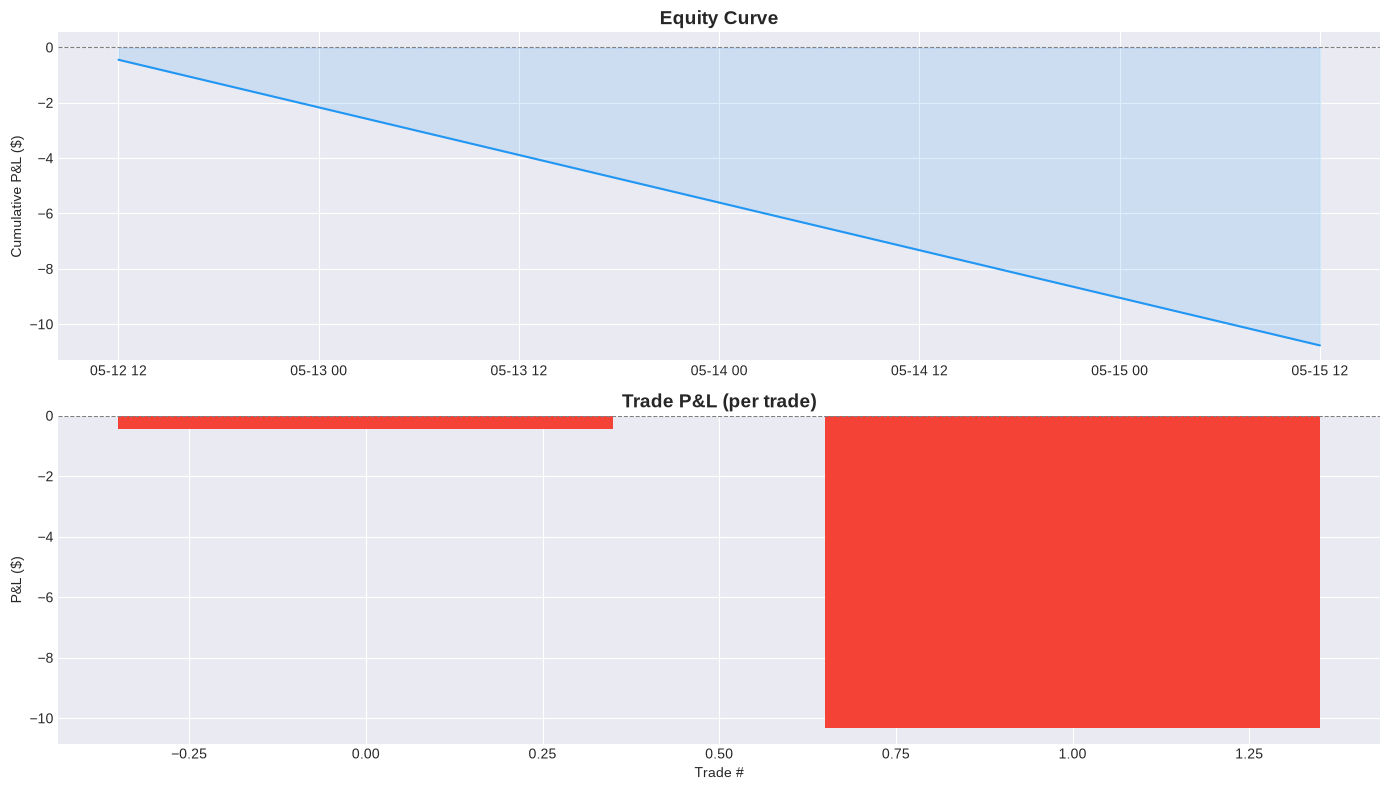

In [ ]:
if len(trades_df) > 0:
    trades_df['cumulative_pnl'] = trades_df['pnl_usdt'].cumsum()
    cum_pnl = trades_df.set_index('exit_time')['cumulative_pnl']

    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Equity curve
    axes[0].plot(cum_pnl.index, cum_pnl.values, linewidth=1.5, color='#2196f3')
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].set_title('Equity Curve', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Cumulative P&L ($)')
    axes[0].fill_between(cum_pnl.index, cum_pnl.values, 0, alpha=0.15, color='#2196f3')

    # Trade P&L bars
    colors = ['#4caf50' if x > 0 else '#f44336' for x in trades_df['pnl_usdt']]
    axes[1].bar(range(len(trades_df)), trades_df['pnl_usdt'], color=colors, width=0.7)
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[1].set_title('Trade P&L (per trade)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Trade #')
    axes[1].set_ylabel('P&L ($)')

    plt.tight_layout()
    plt.show()
else:
    print('No trades — nothing to plot.')

## 5. Trade Log

In [ ]:
if len(trades_df) > 0:
    print('All trades:')
    display_df = trades_df[[
        'entry_time', 'exit_time', 'side', 'entry_price', 'exit_price',
        'stop_price', 'exit_reason', 'pnl_usdt', 'roi_pct'
    ]].copy()
    display_df['pnl_usdt'] = display_df['pnl_usdt'].round(2)
    display_df['roi_pct'] = display_df['roi_pct'].round(2)
    display_df
else:
    print('No trades.')

All trades:
